In [107]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
from pprint import pprint
import pickle as pkl

from tqdm.auto import tqdm
import numpy as np
import pandas as pd

import torch
import torch.optim as optim
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'torch device: {device}')

# GNN package
from torch_geometric.loader import DataLoader
import networkx as nx

# Visualization
import cv2
import matplotlib.pyplot as plt

torch device: cuda


In [108]:
from solo2graph import Graph, PairedGraph
from dataset import CustomDataset, transform_data
from models import CustomModel
from losses import CustomCriterion
from eva import compute_eval, compute_corr
from viz_utils import read_img, viz_corr

In [109]:
SOLO_NAME =  'poisson5r16'
SCENE = 'SimpleOffice'
# SOLO_NAME = 'D_pois3r8'
# SCENE = 'WP16'
DATA_DIR = f'data/{SCENE}/{SOLO_NAME}'
GRAPH_DIR = f'{DATA_DIR}/paired_graph'

CKPT_DIR = f'ckpt/{SCENE}/{SOLO_NAME}_txt'
if not os.path.exists(CKPT_DIR):
    os.makedirs(CKPT_DIR)

In [110]:
ds = CustomDataset(root=GRAPH_DIR, transform=transform_data)
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=False, drop_last=True)
dc = next(iter(dl))

In [111]:
# # e1is = []
# len_e2 = []
# for dc in iter(dl):
#   e1is.append(len(dc['e1i'][0]))
#   len_e2.append(len(dc['e2i'][0]) + len(dc['e2j'][0]))

# len_e2 = np.array(len_e2)
# for k in [1, 3, 5]:
#   p_rand = np.clip(1 - (len_e2 - k) / len_e2, 0, 1)
#   print(f'rand hits@{k}: {p_rand.mean():.4f}, {p_rand.std():.4f}')

In [112]:
ds = CustomDataset(root=GRAPH_DIR, transform=transform_data)

# random select 1000 samples from ds
# ds = torch.utils.data.Subset(ds, np.random.choice(len(ds), 1000, replace=False))

# Do not use batch_size>1 for now, it will crash the e1i, e1j, e2i, e2j indices
train_ds, eval_ds, test_ds = torch.utils.data.random_split(ds, [0.5, 0.2, 0.3], generator=torch.Generator().manual_seed(42))
train_dl = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
eval_dl = DataLoader(eval_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)
# test_dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

print('train size:', len(train_ds))
print('eval size:', len(eval_ds))
print('test size:', len(test_ds))

train size: 1809
eval size: 723
test size: 1084


In [113]:
def data_dict_to_device(data_dict, device):
    for k in data_dict:
        if isinstance(data_dict[k], torch.Tensor):
            data_dict[k] = data_dict[k].to(device)
    return data_dict

In [114]:
def train_step(model, data_dict, optimizer, criterion):
    data_dict = data_dict_to_device(data_dict, device)
    model.train()
    optimizer.zero_grad()
    pred_dict = model(data_dict)
    loss = criterion(pred_dict, data_dict)
    loss.backward()
    optimizer.step()
    return loss.item()

In [115]:
def eval_step(model, data_dict, criterion):
    data_dict = data_dict_to_device(data_dict, device)
    model.eval()
    with torch.no_grad():
        pred_dict = model(data_dict)
        loss = criterion(pred_dict, data_dict)
    metrics = compute_eval(pred_dict, data_dict)
    return loss.item(), metrics

In [116]:
node_attr_dim = 1 # dc['node_attr'].shape[2]
# node_visual_dim = dc['bbox_embs'].shape[2]
edge_attr_dim = dc['edge_attr'].shape[2]
emb_dim = 128

# print(f'node attr dim: {node_attr_dim}')
# print(f'node visual dim: {node_visual_dim}')
print(f'edge attr dim: {edge_attr_dim}')
print(f'emb dim: {emb_dim}')

edge attr dim: 3
emb dim: 128


In [94]:
model = CustomModel(node_attr_dim, edge_attr_dim, emb_dim, match_threshold=0.5).to(device)
criterion = CustomCriterion(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

e = 0
history = {'train_loss': [], 'eval_loss': [], 'eval_metrics': []}

In [24]:
# training loop
for _ in tqdm(range(100)):
    e += 1
    train_loss = 0
    for data_dict in train_dl:
        train_loss += train_step(model, data_dict, optimizer, criterion)
    train_loss /= len(train_dl)

    if e % 5 == 0:
        mean_metrics = {}
        sum_eval_loss = 0

        with torch.no_grad():
            model.eval()
            for data_dict in eval_dl:
                eval_loss, metrics = eval_step(model, data_dict, criterion)
                sum_eval_loss += eval_loss
                for k, v in metrics.items():
                    if k in mean_metrics:
                        mean_metrics[k] = mean_metrics.get(k, 0) + v 
                    else:
                        mean_metrics[k] = v

        for k, v in mean_metrics.items():
            mean_metrics[k] = v / len(eval_dl)
        eval_loss = sum_eval_loss / len(eval_dl)

        # torch.save(model.state_dict(), f'{CKPT_DIR}/model_{e}.pth')

        history['train_loss'].append(train_loss)
        history['eval_loss'].append(eval_loss)
        history['eval_metrics'].append(mean_metrics)
        print(f'----- epoch: {e} -----')
        
        print(f'train loss: {train_loss:.6f}')
        print(f'eval  loss: {eval_loss:.6f}')
        print('eval metrics:')
        for k, v in mean_metrics.items():
            print(f'{k}: {v:.4f}')
        print()

plt.plot(history['train_loss'], label='train loss')
plt.plot(history['eval_loss'], label='eval loss')
plt.legend()
plt.figure()
for k, v in history['eval_metrics'][0].items():
    plt.plot([x[k] for x in history['eval_metrics']], label=f'eval {k}')
plt.legend()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

----- epoch: 5 -----
train loss: 1.162955
eval  loss: 1.380860
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 10 -----
train loss: 1.096993
eval  loss: 1.416795
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 15 -----
train loss: 1.080206
eval  loss: 1.357451
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 20 -----
train loss: 1.003245
eval  loss: 1.421633
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 25 -----
train loss: 0.955560
eval  loss: 1.441388
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 30 -----
train loss: 0.894108
eval  loss: 1.449782
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 35 -----
train loss: 0.843991
eval  loss: 1.762528
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0.0000

----- epoch: 40 -----
train loss: 0.781213
eval  loss: 1.545251
eval metrics:
acc: 0.5837
pre: 0.0000
rec: 0.0000
f1: 0

KeyboardInterrupt: 

In [127]:
model.load_state_dict(torch.load(f'{CKPT_DIR}/model_440.pth'))

<All keys matched successfully>

In [128]:
mean_metrics = {}
sum_test_loss = 0
gid2pred = {}

cnt = 0
with torch.no_grad():
    model.eval()
    for data_dict in tqdm(test_dl):
        test_loss, metrics = eval_step(model, data_dict, criterion)

        if data_dict['e1i'].shape[1] < 3:
            continue

        cnt += 1
        pred_dict = model(data_dict) 
        sum_test_loss += test_loss

        g1_step = data_dict['g1_step'][0].item()
        if g1_step not in gid2pred:
            gid2pred[g1_step] = {'pred': [pred_dict], 'data': [data_dict], 'eva': [metrics]}
        else:
            gid2pred[g1_step]['pred'].append(pred_dict)
            gid2pred[g1_step]['data'].append(data_dict)
            gid2pred[g1_step]['eva'].append(metrics)

        for k, v in metrics.items():
            if k in mean_metrics:
                mean_metrics[k] = mean_metrics[k] + v
            else:
                mean_metrics[k] = v
        


for k, v in mean_metrics.items():
    mean_metrics[k] = v / cnt #len(test_dl)

mean_test_loss = sum_test_loss / cnt #len(test_dl)
print(f'mean_test loss: {mean_test_loss:.4f}')
print('test metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.4f}')

  0%|          | 0/1084 [00:00<?, ?it/s]

mean_test loss: nan
test metrics:
pre: 0.0000
rec: 0.0000
f1: 0.0000


### viz matching

gt	8	tp	0	fp	0	fn	8
gt	1	tp	0	fp	0	fn	1
gt	5	tp	0	fp	2	fn	3
gt	4	tp	3	fp	1	fn	0
gt	18	tp	12	fp	3	fn	3
gt	2	tp	1	fp	0	fn	1
gt	2	tp	0	fp	0	fn	2
gt	1	tp	0	fp	0	fn	1
gt	3	tp	0	fp	1	fn	2
gt	5	tp	1	fp	2	fn	2
gt	25	tp	0	fp	1	fn	24


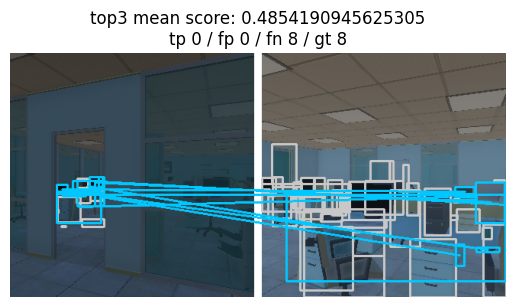

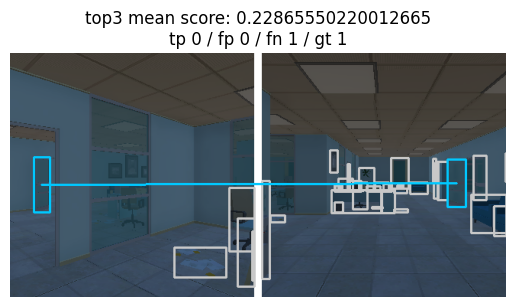

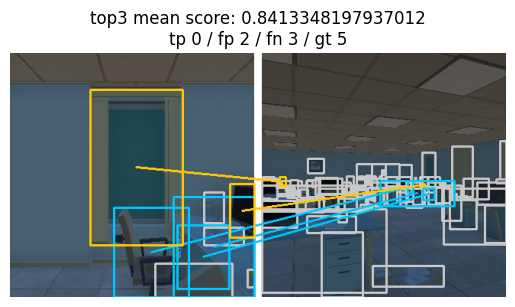

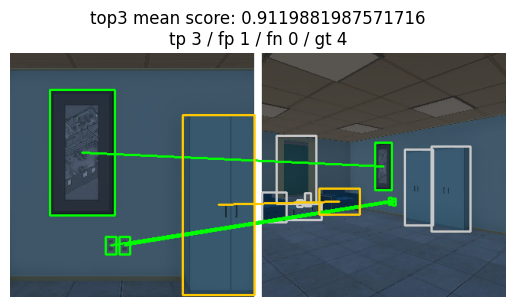

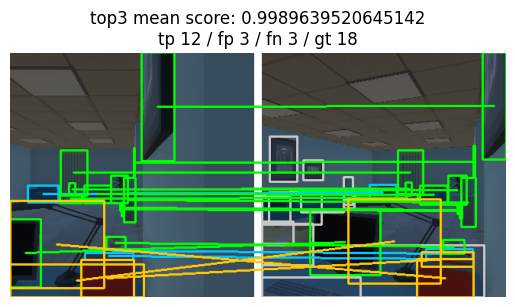

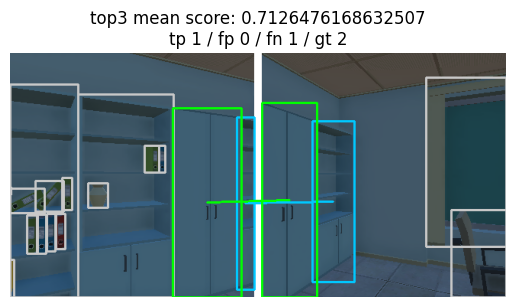

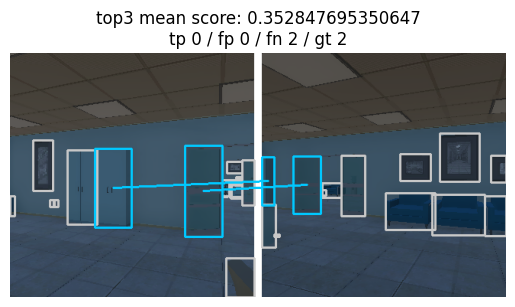

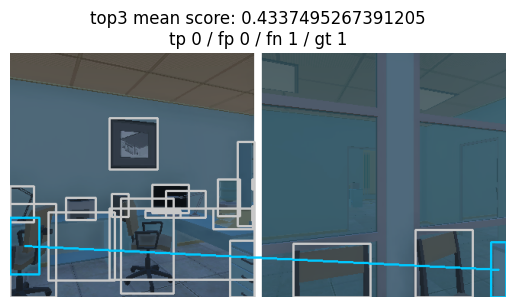

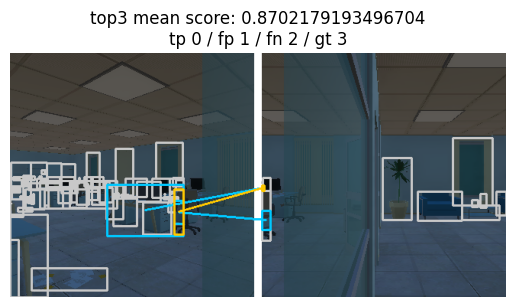

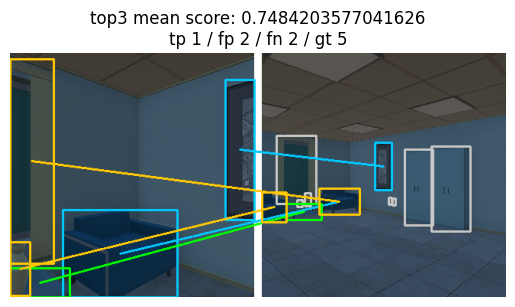

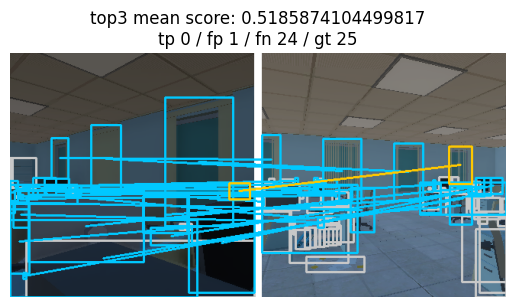

In [124]:
cnt = 0
with torch.no_grad():
    model.eval()
    for data_dict in eval_dl:
        cnt += 1
        if cnt < 10:
            continue
        data_dict_to_device(data_dict, device)
        pred_dict = model(data_dict)

        img, tp_corr, fp_corr, fn_corr, gt_corr = viz_corr(pred_dict, data_dict, data_dir=DATA_DIR, img_type='rgb')

        print('gt', len(gt_corr), 'tp', len(tp_corr), 'fp', len(fp_corr), 'fn', len(fn_corr), sep='\t')

        top3_mean_score = pred_dict['matching_scores0'].sort(descending=True)[0][:3].mean().item()
        plt.figure()
        plt.title(f'top3 mean score: {top3_mean_score}\ntp {len(tp_corr)} / fp {len(fp_corr)} / fn {len(fn_corr)} / gt {len(gt_corr)}')
        plt.imshow(img)
        plt.axis('off')
        if cnt == 20:
            break

In [61]:
res = []

for gid, v in gid2pred.items():
    g1_pose = v['data'][0]['g1_camera_pose'][0]
    g1_step = v['data'][0]['g1_step'][0].item()
    g2_step = v['data'][0]['g2_step'][0].item()

    preds = []

    gt_pose = None
    gt_step = -1
    gt_pos_loss = np.inf
    gt_q_loss = np.inf

    for idx in range(len(v['pred'])):
        pred_dict = v['pred'][idx]
        data_dict = v['data'][idx]

        g1_pose = data_dict['g1_camera_pose'][0].cpu()
        g1_step = data_dict['g1_step'][0].item()
        g2_pose = data_dict['g2_camera_pose'][0].cpu()
        g2_step = data_dict['g2_step'][0].item()
        pos_loss = np.linalg.norm(g1_pose[:3] - g2_pose[:3]).item()
        q_loss = np.linalg.norm(g1_pose[3:] - g2_pose[3:]).item()

        # pred
        match_mask = (pred_dict['matches0'] != -1)
        if sum(match_mask) == 0:
            score = -np.inf
            continue
        else:
            match_score = pred_dict['matching_scores0'][match_mask].sort(descending=True)[0][:3]
            score = torch.mean(match_score).item()
        preds.append({
            'pred': pred_dict,
            'data': data_dict,
            'score': score, 
            'g2_step': g2_step, 
            'g2_pose': g2_pose,
            'pos_loss': pos_loss,
            'q_loss': q_loss,
        })

        # gt
        if pos_loss < gt_pos_loss:
            gt_pos_loss = pos_loss
            gt_q_loss = q_loss
            gt_pose = g2_pose.numpy()
            gt_step = g2_step
        if pos_loss == gt_pos_loss and q_loss < gt_q_loss:
            gt_pos_loss = pos_loss
            gt_q_loss = q_loss
            gt_pose = g2_pose.numpy()
            gt_step = g2_step

    preds = sorted(preds, key=lambda x: x['score'], reverse=True)


    # print(f'g1_step: {g1_step}')
    # print(f'gt_step: {gt_step}')
    # print(f'pred: {[p[0] for p in pred]}')
    # print()
    res.append({
        'g1_step': g1_step, 
        'gt_step': gt_step,
        'gt_pose': gt_pose,
        'preds': preds,
    })


def compute_hits_at_k(gt, pred, k):
    for i in range(min(len(pred), k)):
        if np.allclose(pred[i]['pos_loss'], 0):
            return True
    return False

res = sorted(res, key=lambda x: x['g1_step'])

mean_len_of_pred = np.mean([len(d['preds']) for d in res])
std_len_of_pred = np.std([len(d['preds']) for d in res])
max_len_of_pred = np.max([len(d['preds']) for d in res])
print(f'mean_len_of_pred: {mean_len_of_pred:.4f}')
print(f'std_len_of_pred: {std_len_of_pred:.4f}')
print(f'max_len_of_pred: {max_len_of_pred:.4f}')
print()

# n_data = len(res)
# n_no_match = sum([len(d['preds']) == 0 for d in res])
# n_has_match = n_data - n_no_match
# n_hits_at_1 = sum([compute_hits_at_k(d['gt_pose'], d['preds'], 1) for d in res])
# n_hits_at_3 = sum([compute_hits_at_k(d['gt_pose'], d['preds'], 3) for d in res])
# n_hits_at_5 = sum([compute_hits_at_k(d['gt_pose'], d['preds'], 5) for d in res])
# n_hits_at_10 = sum([compute_hits_at_k(d['gt_pose'], d['preds'], 10) for d in res])
# print(f'data len: {n_data}')
# print(f'num of has , no matches: {n_has_match} , {n_no_match}')
# print(f'hits@1: {n_hits_at_1 / (n_has_match) * 100:.4f}%')
# print(f'hits@3: {n_hits_at_3 / (n_has_match) * 100:.4f}%')
# print(f'hits@5: {n_hits_at_5 / (n_has_match) * 100:.4f}%')
# print(f'hits@10: {n_hits_at_10 / (n_has_match) * 100:.4f}%')

mean_len_of_pred: 13.7714
std_len_of_pred: 9.6668
max_len_of_pred: 42.0000



10 case of hits in range (0, 100)


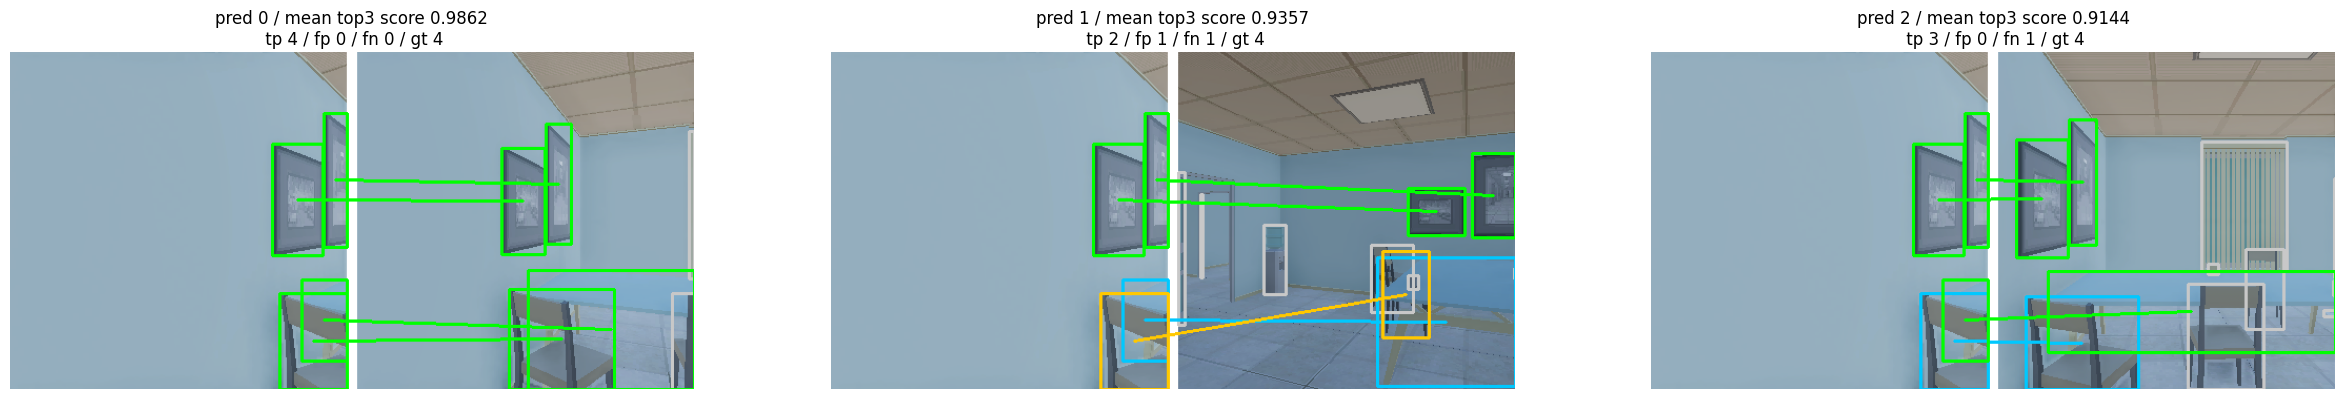

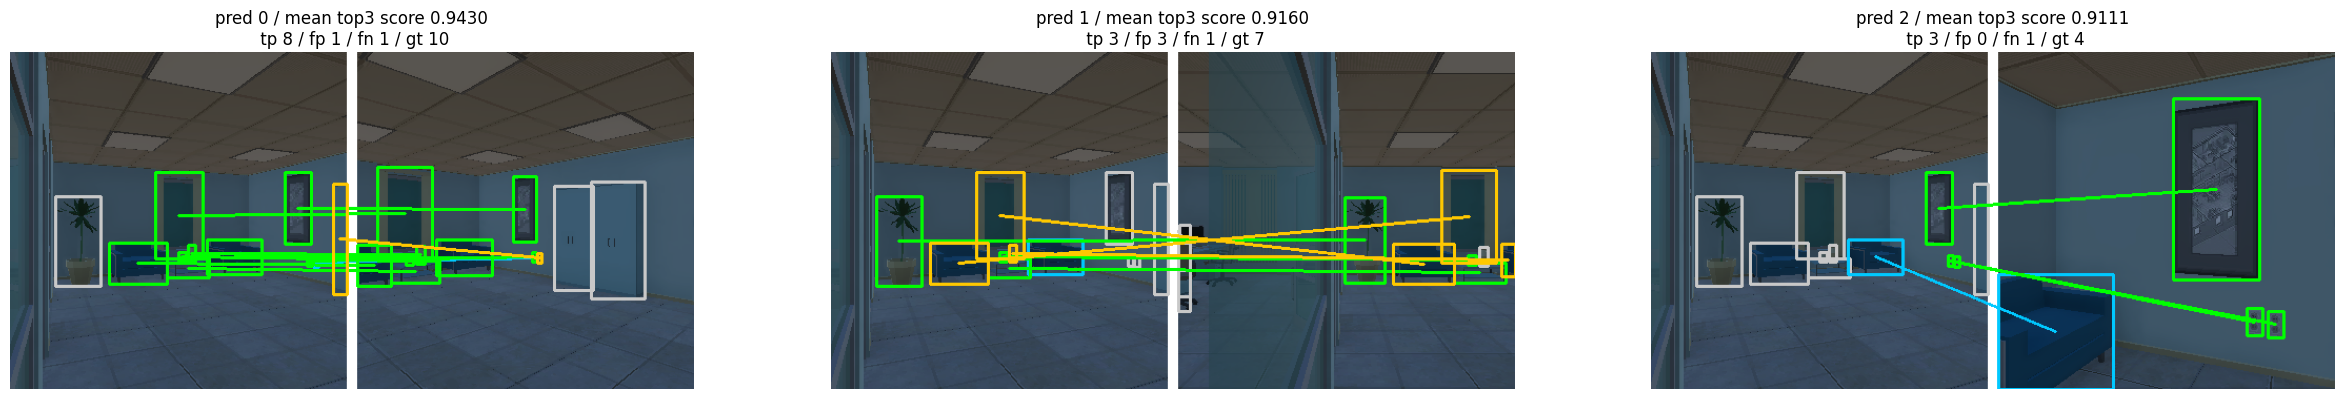

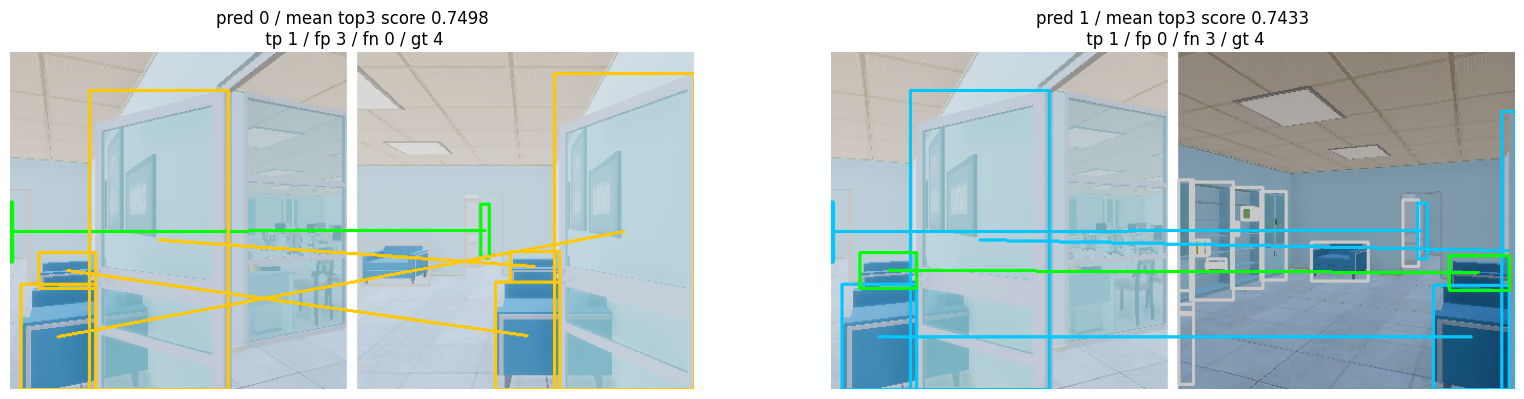

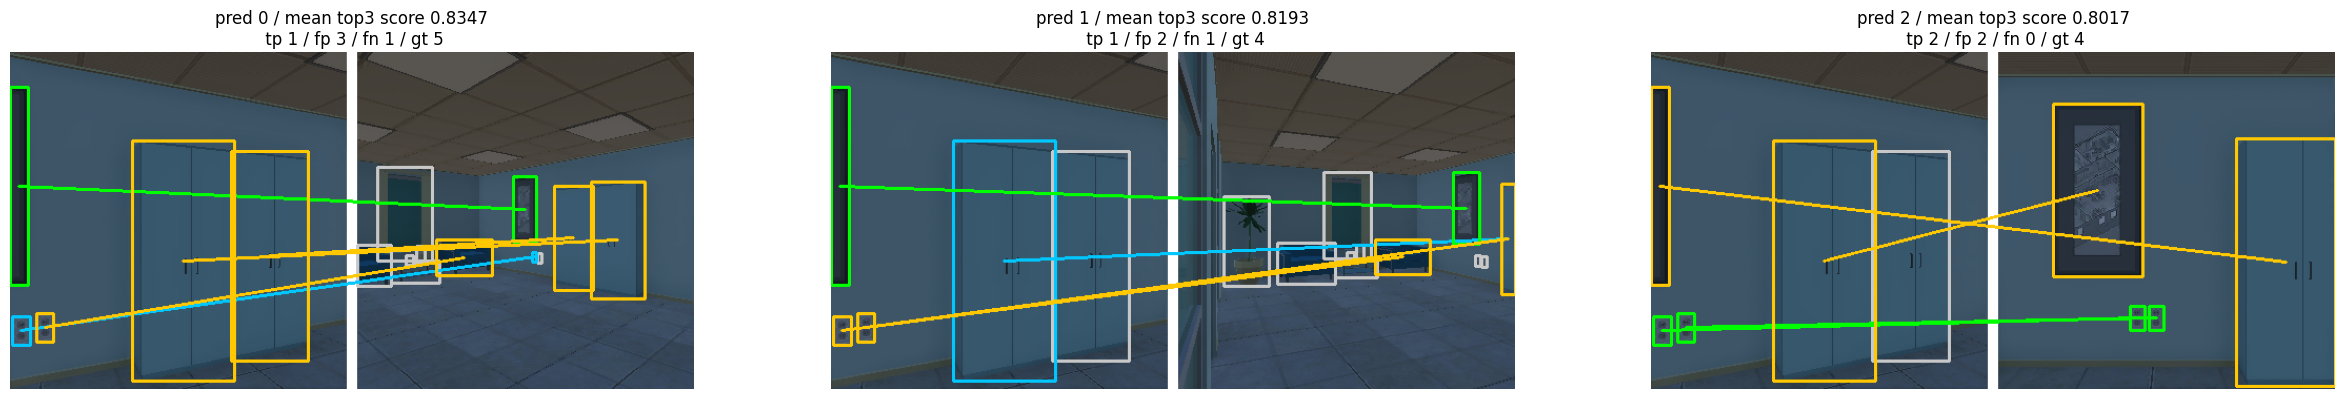

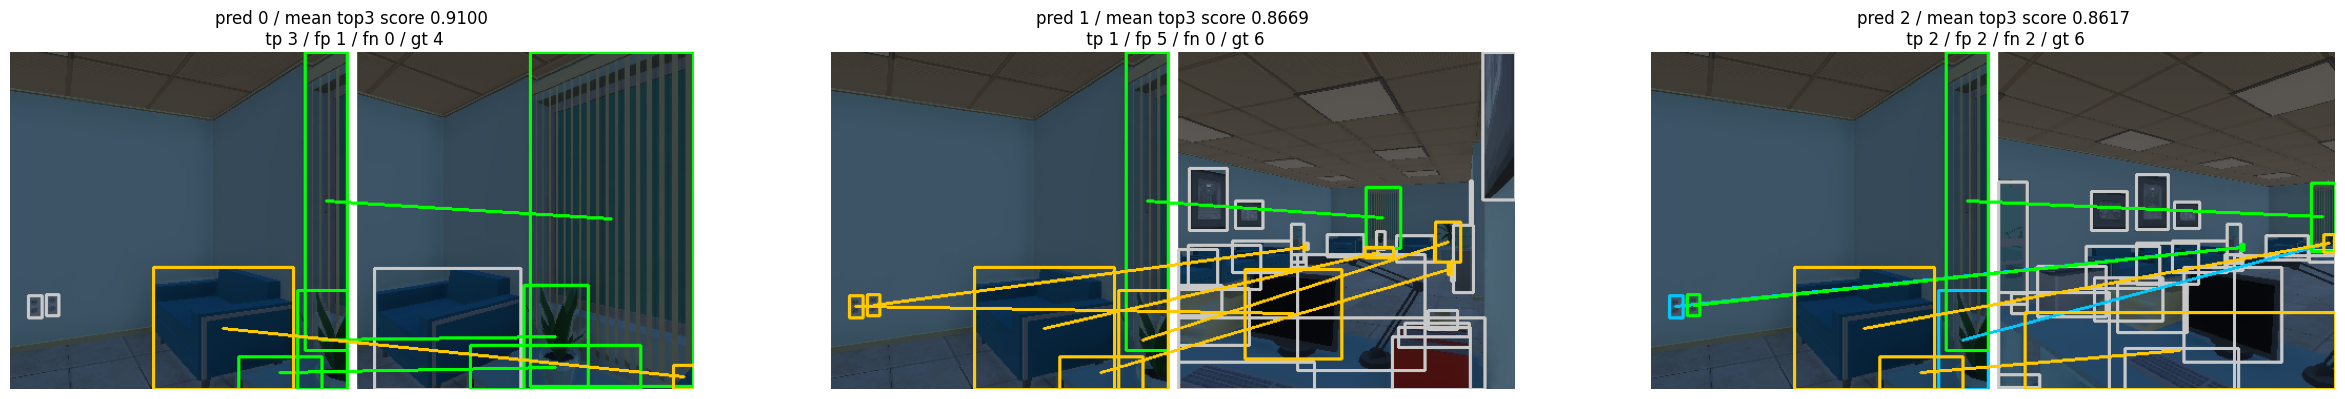

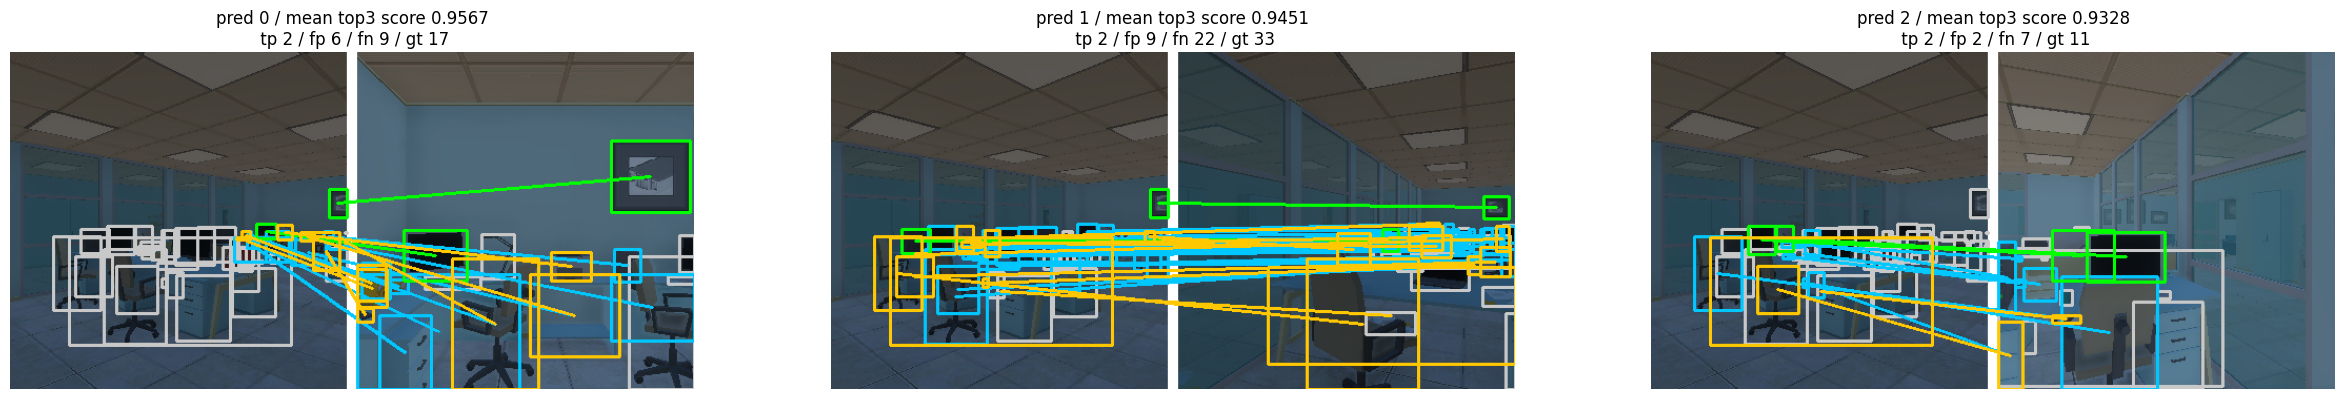

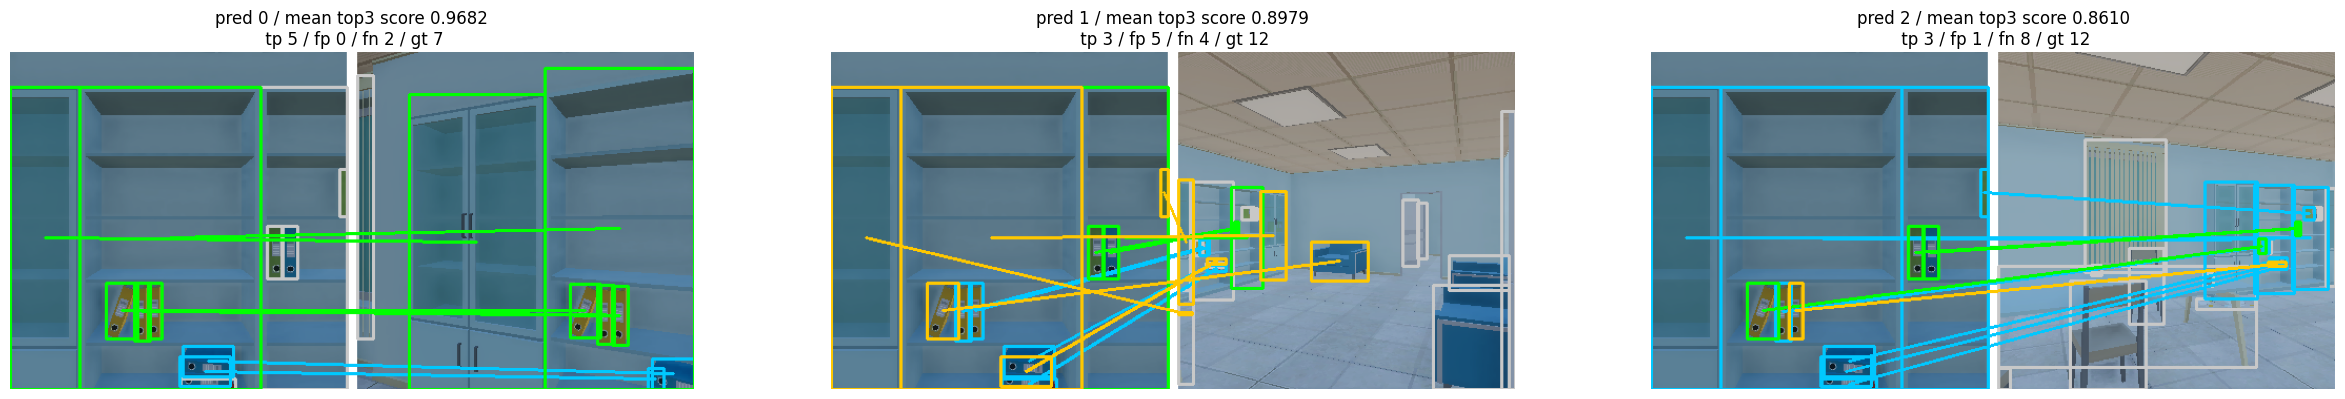

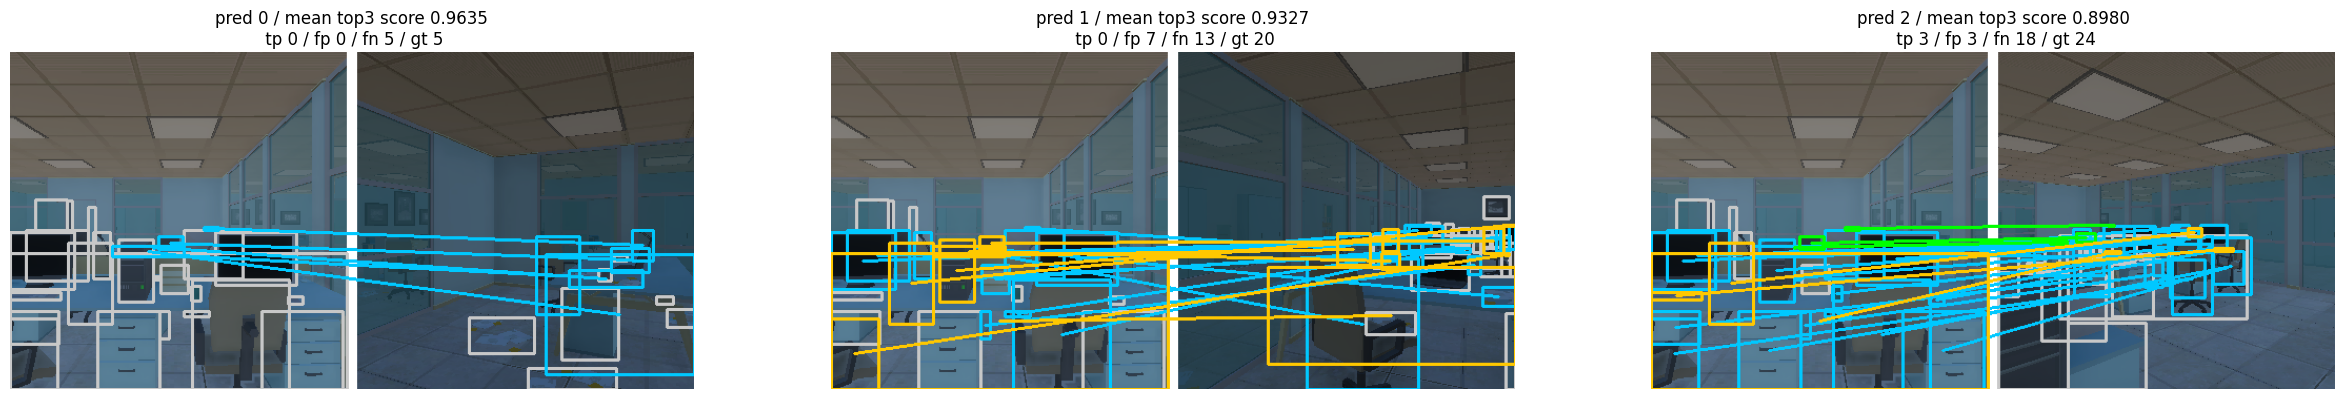

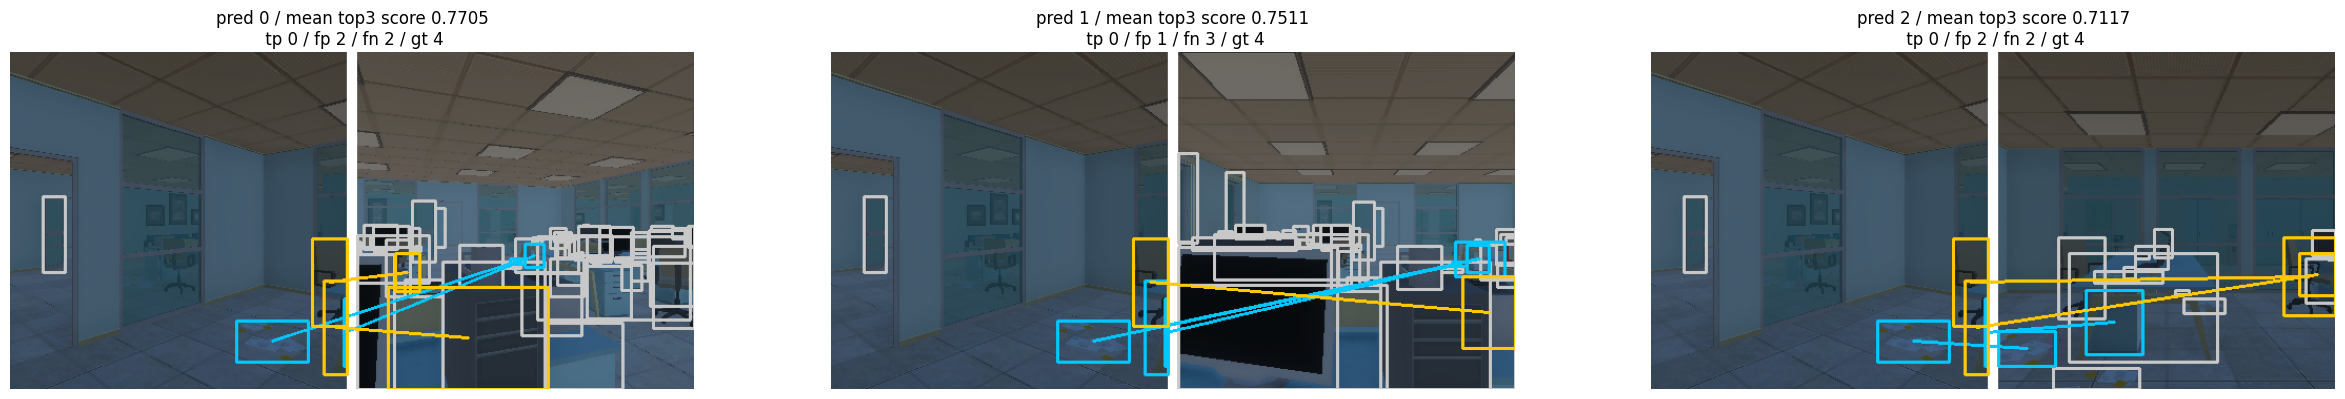

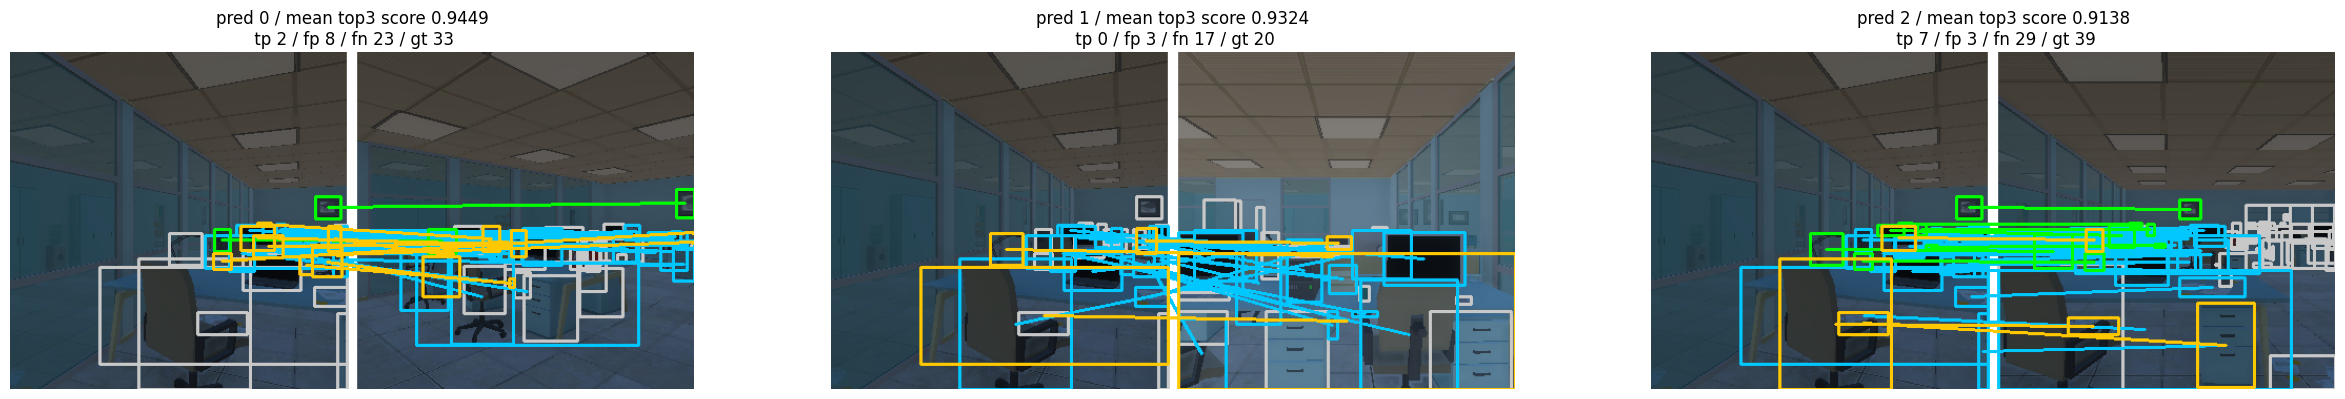

In [75]:
def gen_vis_data(res, idx, max_len=5, vis_type='sem_seg'):
    g1_step = res[idx]['g1_step']
    pred_g2_steps = [d['g2_step'] for d in res[idx]['preds']]
    pred_g2_score = [d['score'] for d in res[idx]['preds']]

    plt.figure(figsize=(30, 15))
    plt.subplot(1, max_len, 1)
    plt.axis('off')
    # plt.title(f'query {g1_step}, hit at {k} in {len(pred_g2_steps)}')
    # vis_corr(res[idx]['preds'][k]['pred'], res[idx]['preds'][k]['data'], img_type=vis_type)
    # plt.imshow(read_img(g1_step, data_dir=DATA_DIR, type=vis_type))

    for i in range(min(max_len, len(pred_g2_steps))):
        plt.subplot(1, max_len, i + 1)
        plt.axis('off')
        # plt.title(f'pred {i} / score {pred_g2_score[i]:.4f}\npos_loss: {res[idx]["preds"][i]["pos_loss"]:.4f} / q_loss: {res[idx]["preds"][i]["q_loss"]:.4f}')
        img, tp_corr, fp_corr, fn_corr, gt_corr = viz_corr(res[idx]['preds'][i]['pred'], res[idx]['preds'][i]['data'], data_dir=DATA_DIR, img_type=vis_type)
        plt.title(f'pred {i} / mean top3 score {pred_g2_score[i]:.4f}\n tp {len(tp_corr)} / fp {len(fp_corr)} / fn {len(fn_corr)} / gt {len(gt_corr)}')
        plt.imshow(img)

    return g1_step, pred_g2_steps, pred_g2_score

n_sample = 10
i_list = np.arange(len(res))
np.random.shuffle(i_list)
range_min = 0
range_max = 100
sample_cnt = 0
for i in i_list:
    gt_pose = res[i]['gt_pose']
    preds = res[i]['preds']
    k = -1
    # print(f'gt_pose: {gt_pose[:3]}')
    # print(f'pred_pose: {pred_g2_poses[0][:3]}')
    for k, pred in enumerate(preds):
        if np.allclose(pred['pos_loss'], 0):
            # print(f'idx: {i}, hit at {k} over {len(pred)}')
            # print()
            break
    if range_min <= k < range_max:
        sample_cnt += 1
        _ = gen_vis_data(res, i, max_len=3, vis_type='rgb')
        if sample_cnt == n_sample:
            break

print(f'{sample_cnt} case of hits in range ({range_min}, {range_max})')